## EDA and OLS-based MMM Modeling

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error

# Load the dataset
df = pd.read_excel('Case_Study_Input_File.xlsx', sheet_name='model_data')

# Drop spend-related columns except 'ventes_avenue_spends_mn'
spend_columns = [col for col in df.columns if 'spend' in col.lower()]
spend_columns = [col for col in spend_columns if col not in ['ventes_avenue_spends_mn', 'trade_promo_spends_mn','consumer_promo_spends_mn']]
df = df.drop(columns=spend_columns)


In [21]:
# Display the first few rows of the dataframe
df.head()

,date,kpi_val_sales_mn,vol_sales_mn,wtd_dist_max,num_dist_max,trade_promo_spends_mn,consumer_promo_spends_mn,newspaper_impressions,tv_total_grp,tv_spots,...,youtube_impressions_mn,fb_ig_clicks,fb_ig_impressions_mn,whatsapp_clicks,whatsapp_impressions_mn,jio_clicks,jio_impressions_mn,hotstar_clicks,hotstar_impressions_mn,ventes_avenue_spends_mn
0,2019-01-01,232.467056,302.394,60.339142,28.076869,6.386184,0.000000,0,300.21,592,...,0.0000,0,0.000000,0,0.0,0,0.0,0,0.000000,0.0
1,2019-02-01,214.927168,279.889,60.897473,28.184146,6.903101,0.000000,22,397.51,1331,...,0.0000,0,0.000000,0,0.0,0,0.0,0,0.000000,0.0
2,2019-03-01,243.621484,318.025,60.356401,28.494586,6.378913,0.000000,11,184.26,780,...,13.5788,43420,8.665885,0,0.0,0,0.0,3545,2.533335,0.0
3,2019-04-01,251.191704,328.868,58.884626,28.637880,6.807898,0.960220,0,0.00,0,...,0.0000,0,0.000000,0,0.0,0,0.0,0,0.000000,0.0
4,2019-05-01,243.752604,318.636,60.130245,28.579280,4.139811,0.770213,0,317.83,1114,...,3.7910,0,0.000000,0,0.0,0,0.0,0,0.000000,0.0


In [22]:
#Price Calculation
df['Price']=df['kpi_val_sales_mn']/df['vol_sales_mn']

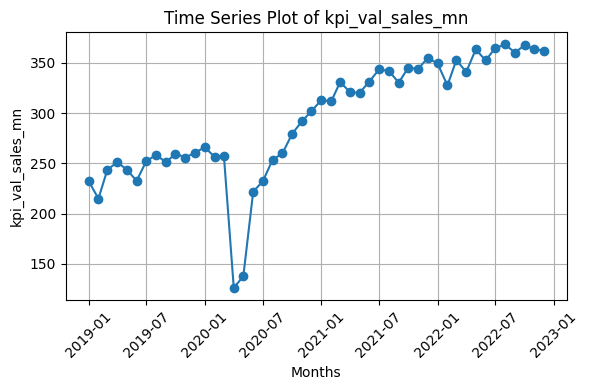

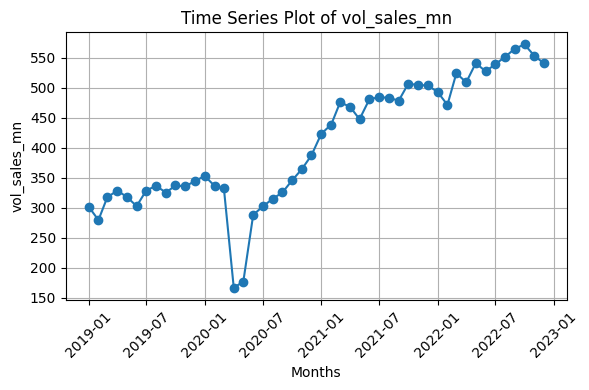

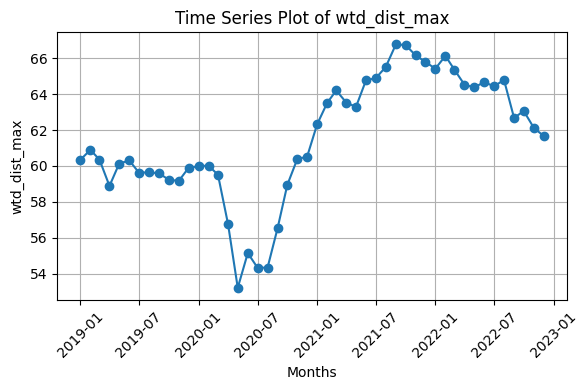

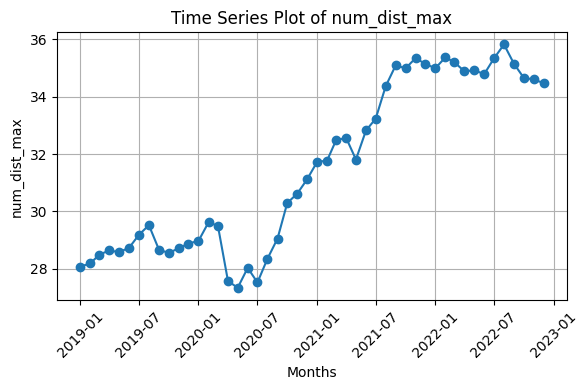

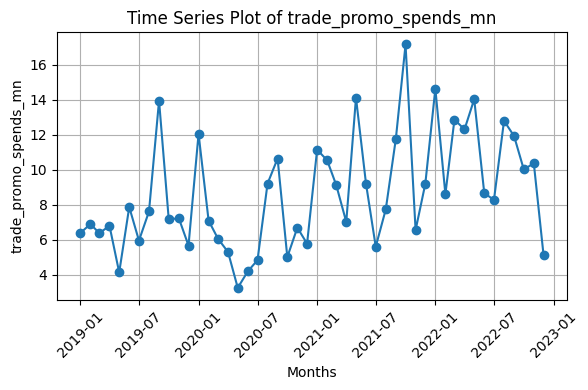

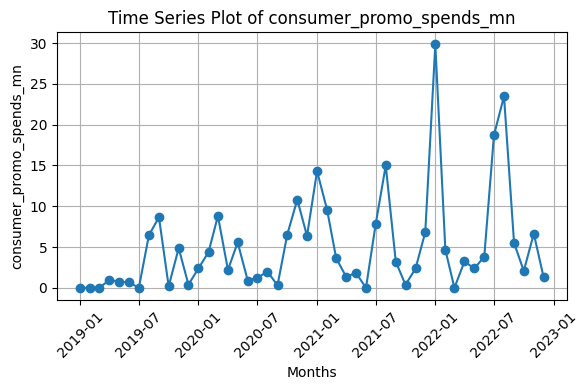

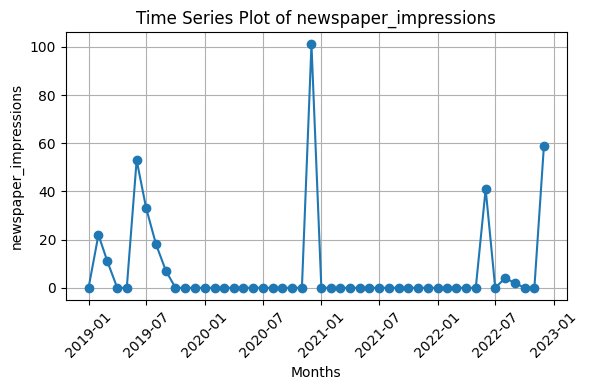

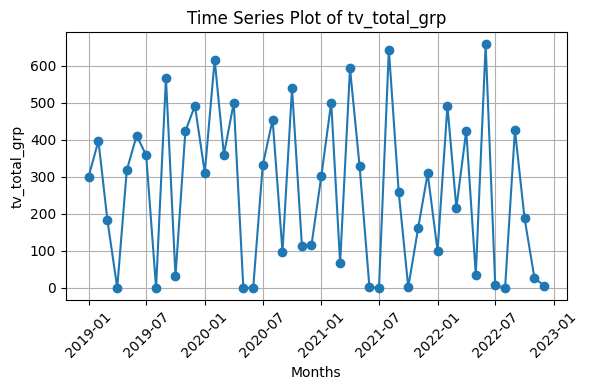

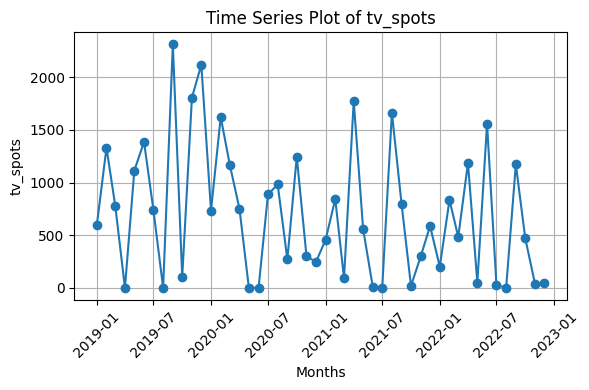

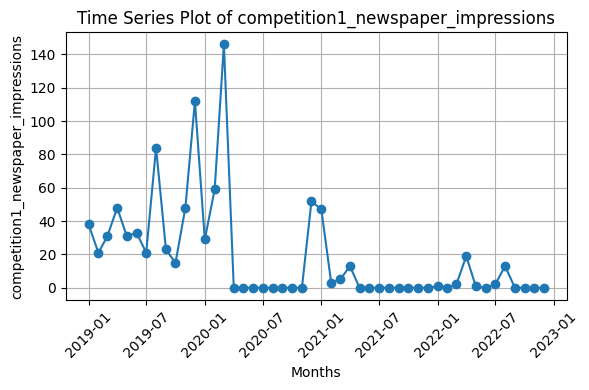

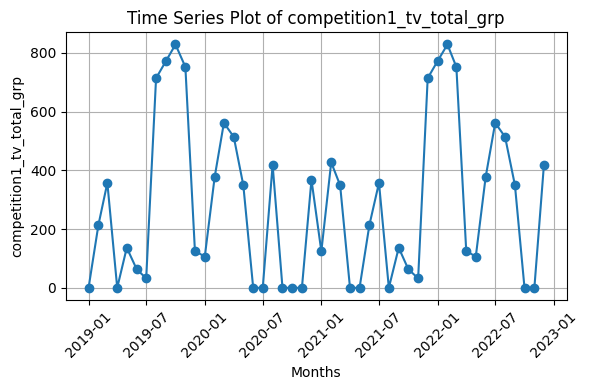

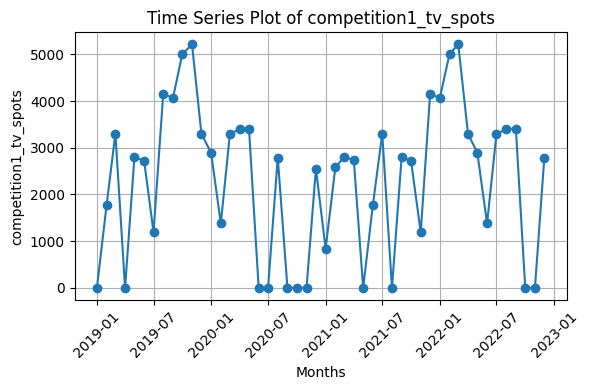

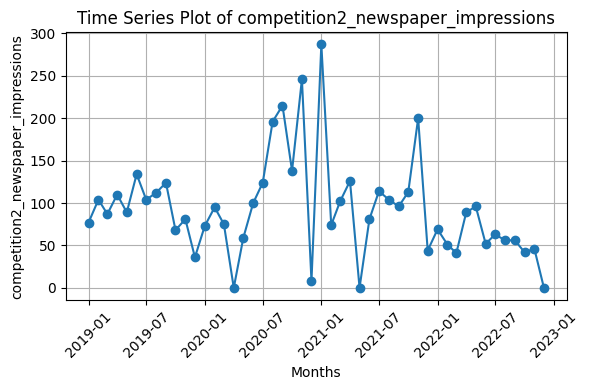

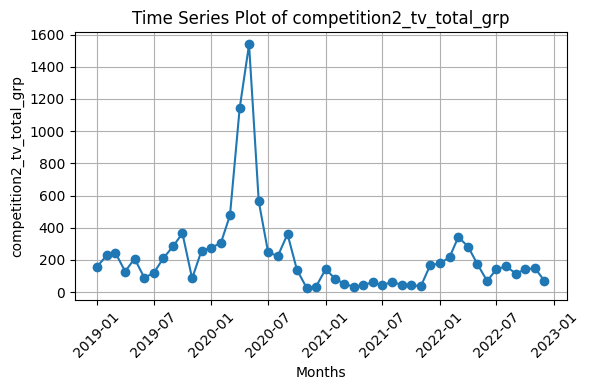

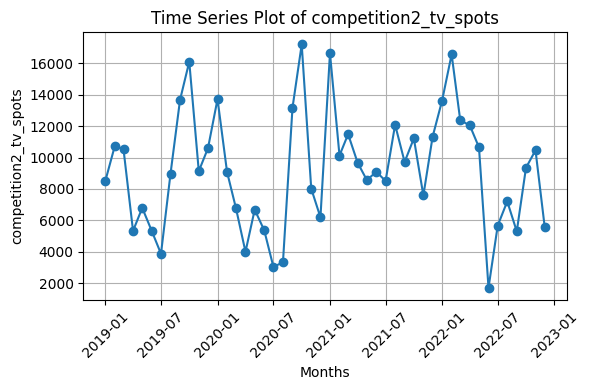

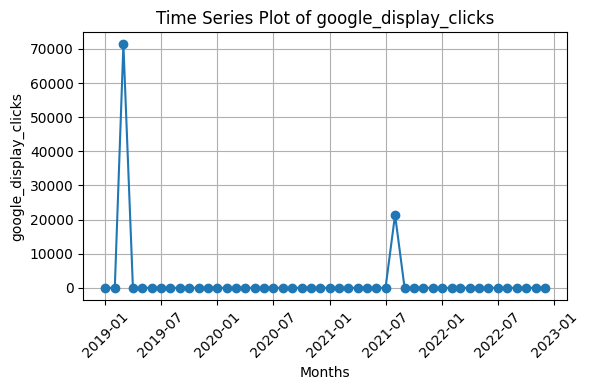

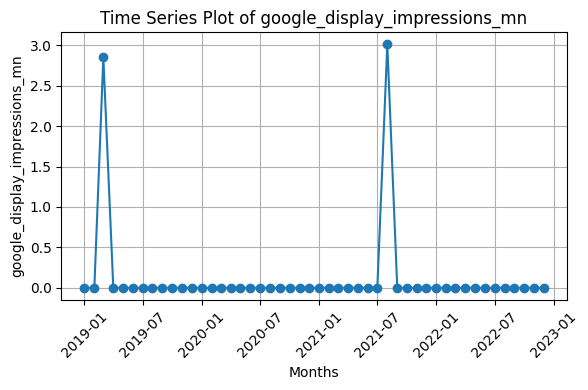

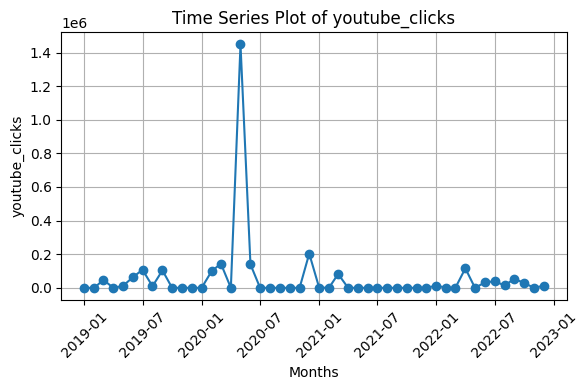

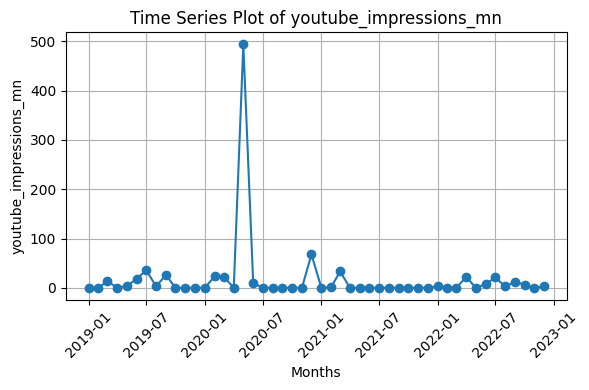

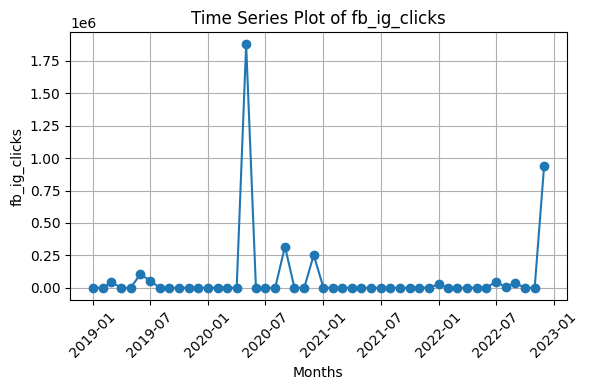

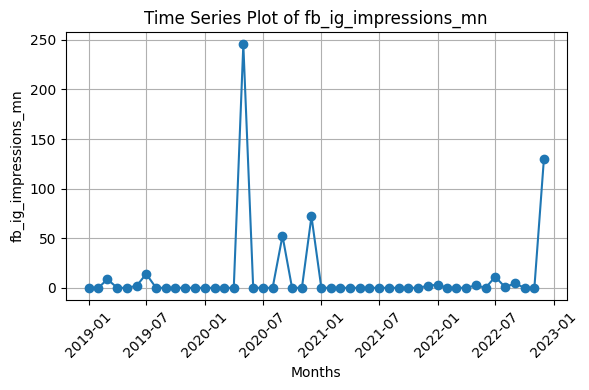

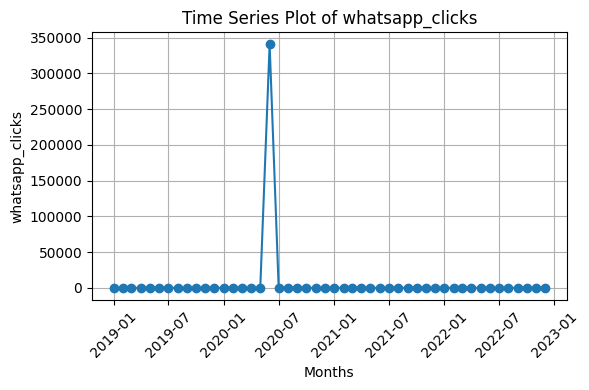

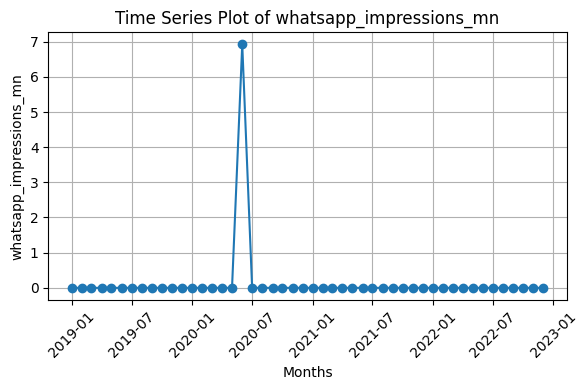

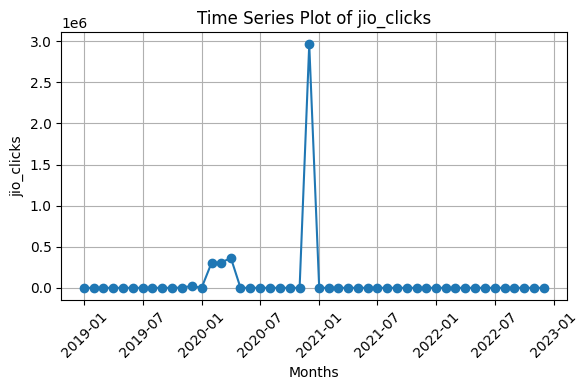

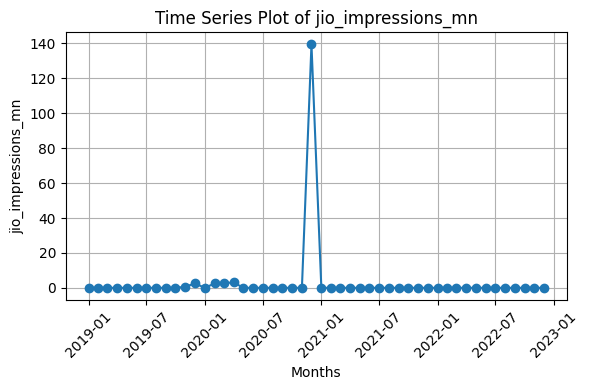

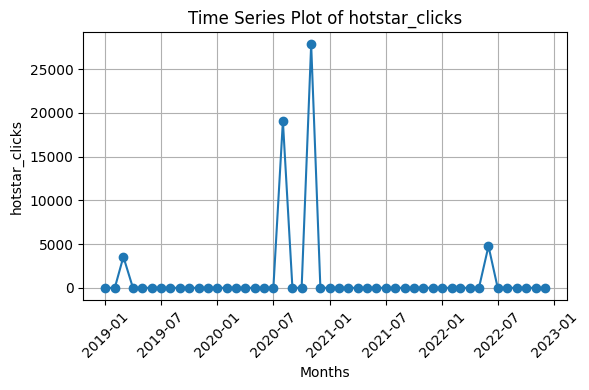

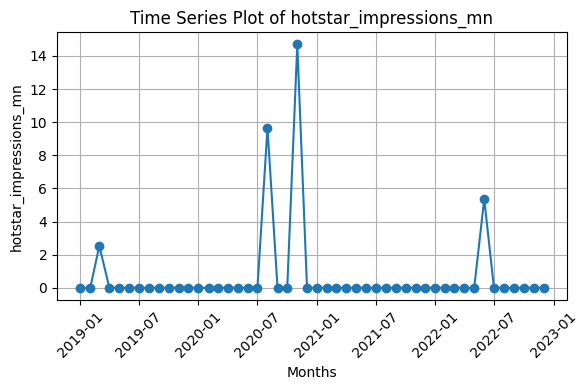

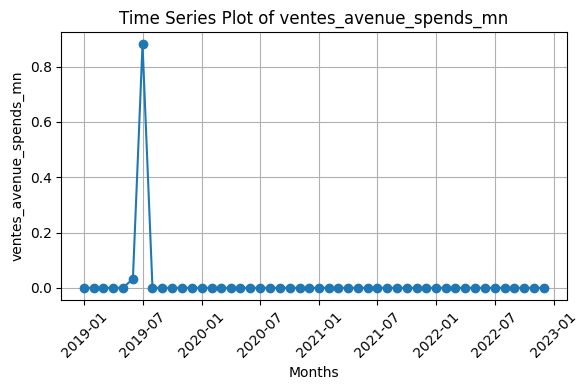

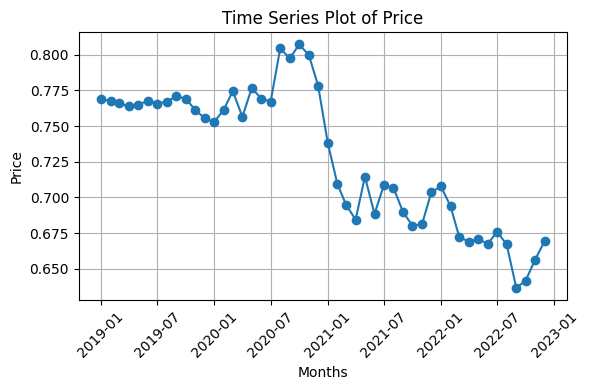

In [23]:
# List of variables to plot
variables =df.columns[1:]

# Create time series plots for each variable
for variable in variables:
    plt.figure(figsize=(6, 4))
    plt.plot(df["date"], df[variable], marker='o')
    plt.title(f'Time Series Plot of {variable}')
    plt.xlabel('Months')
    plt.ylabel(variable)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [24]:
# Exploratory Data Analysis (EDA)
# Summary statistics(First column contains months,hence not included)
df.iloc[:,1:].describe()

,kpi_val_sales_mn,vol_sales_mn,wtd_dist_max,num_dist_max,trade_promo_spends_mn,consumer_promo_spends_mn,newspaper_impressions,tv_total_grp,tv_spots,competition1_newspaper_impressions,...,fb_ig_clicks,fb_ig_impressions_mn,whatsapp_clicks,whatsapp_impressions_mn,jio_clicks,jio_impressions_mn,hotstar_clicks,hotstar_impressions_mn,ventes_avenue_spends_mn,Price
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,...,4.800000e+01,48.000000,48.000000,48.000000,4.800000e+01,48.000000,48.000000,48.000000,48.000000,48.000000
mean,293.722501,409.403229,61.553713,31.537910,8.646890,5.047986,7.31250,264.092001,700.958333,18.687500,...,7.732112e+04,11.428664,7094.145833,0.144167,8.252008e+04,3.141996,1149.041667,0.671736,0.019000,0.728408
std,59.224222,105.461019,3.482679,2.947466,3.236527,6.276398,19.40186,212.433525,639.050391,30.884243,...,3.025174e+05,41.057624,49149.684079,0.998816,4.316646e+05,20.101377,4853.979179,2.619891,0.127003,0.048510
min,126.291278,166.944000,53.203745,27.335125,3.261926,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.636675
25%,253.159445,328.149000,59.617900,28.702618,6.300529,0.862939,0.00000,34.022500,81.500000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.683641
50%,306.686986,405.809000,61.286741,31.419246,7.807479,2.797708,0.00000,301.405000,589.500000,1.500000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.745674
75%,344.195365,504.379750,64.566022,34.815109,10.767277,6.550619,0.00000,425.205000,1169.750000,29.500000,...,9.815000e+02,1.005000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.767762
max,368.123912,572.466934,66.772684,35.823721,17.150717,29.834155,101.00000,657.800000,2311.000000,146.000000,...,1.875737e+06,245.330000,340519.000000,6.920000,2.960579e+06,139.410000,27801.000000,14.690000,0.880000,0.807153


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   date                                48 non-null     datetime64[ns]
 1   kpi_val_sales_mn                    48 non-null     float64       
 2   vol_sales_mn                        48 non-null     float64       
 3   wtd_dist_max                        48 non-null     float64       
 4   num_dist_max                        48 non-null     float64       
 5   trade_promo_spends_mn               48 non-null     float64       
 6   consumer_promo_spends_mn            48 non-null     float64       
 7   newspaper_impressions               48 non-null     int64         
 8   tv_total_grp                        48 non-null     float64       
 9   tv_spots                            48 non-null     int64         
 10  competition1_newspaper_impre

In [26]:
# Check for missing values
df.isnull().sum()

date                                  0
kpi_val_sales_mn                      0
vol_sales_mn                          0
wtd_dist_max                          0
num_dist_max                          0
trade_promo_spends_mn                 0
consumer_promo_spends_mn              0
newspaper_impressions                 0
tv_total_grp                          0
tv_spots                              0
competition1_newspaper_impressions    0
competition1_tv_total_grp             0
competition1_tv_spots                 0
competition2_newspaper_impressions    0
competition2_tv_total_grp             0
competition2_tv_spots                 0
google_display_clicks                 0
google_display_impressions_mn         0
youtube_clicks                        0
youtube_impressions_mn                0
fb_ig_clicks                          0
fb_ig_impressions_mn                  0
whatsapp_clicks                       0
whatsapp_impressions_mn               0
jio_clicks                            0


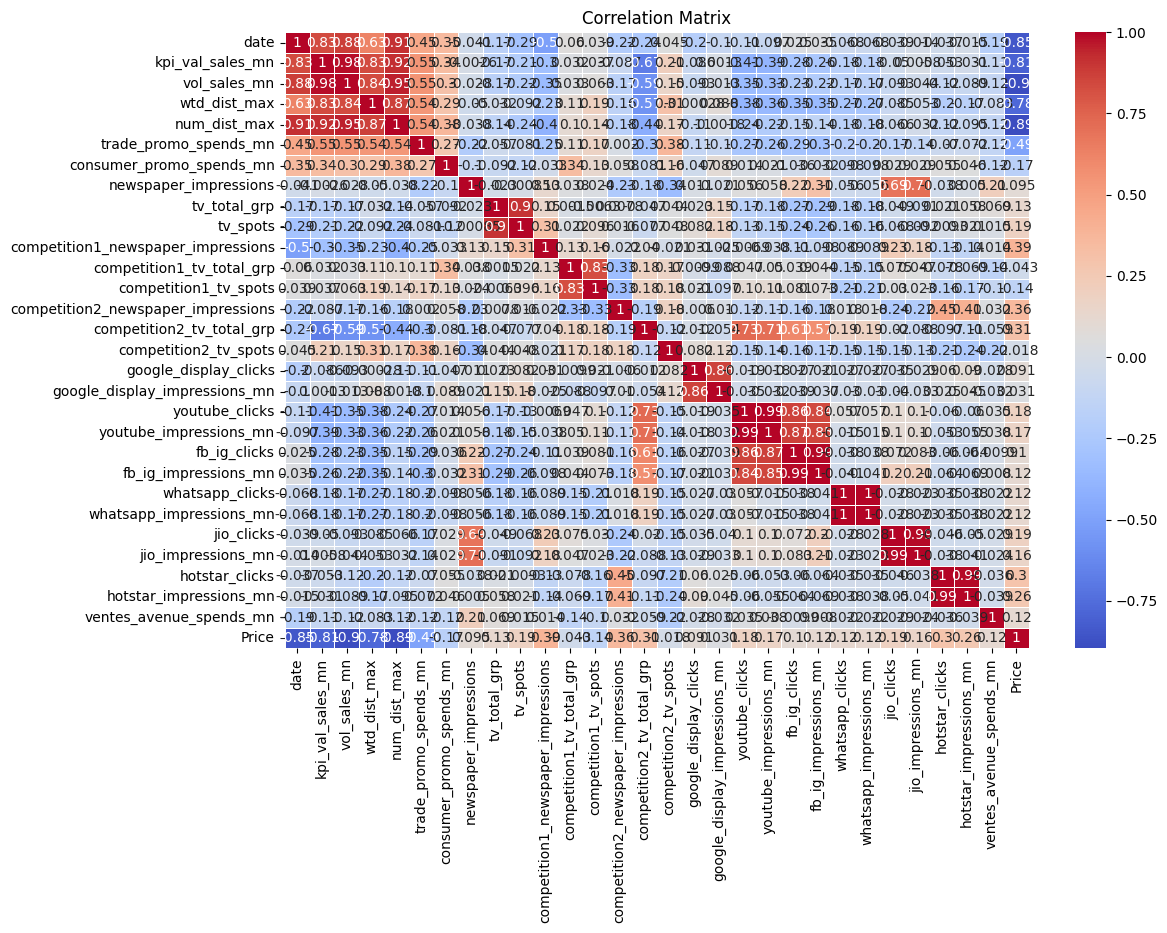

In [27]:
# Correlation matrix
correlation_matrix = df.corr()
# Plotting the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [28]:
# Correlation between sales and sales drivers
df.corr()['kpi_val_sales_mn'].sort_values(ascending=False)

kpi_val_sales_mn                      1.000000
vol_sales_mn                          0.984079
num_dist_max                          0.924293
date                                  0.833812
wtd_dist_max                          0.830255
trade_promo_spends_mn                 0.547386
consumer_promo_spends_mn              0.340433
competition2_tv_spots                 0.208453
competition1_tv_spots                 0.036907
competition1_tv_total_grp             0.032279
jio_impressions_mn                    0.005761
google_display_impressions_mn         0.001263
newspaper_impressions                -0.002613
hotstar_impressions_mn               -0.031369
jio_clicks                           -0.050080
hotstar_clicks                       -0.052957
google_display_clicks                -0.085520
competition2_newspaper_impressions   -0.086827
ventes_avenue_spends_mn              -0.109414
tv_total_grp                         -0.168766
whatsapp_impressions_mn              -0.178687
whatsapp_clic

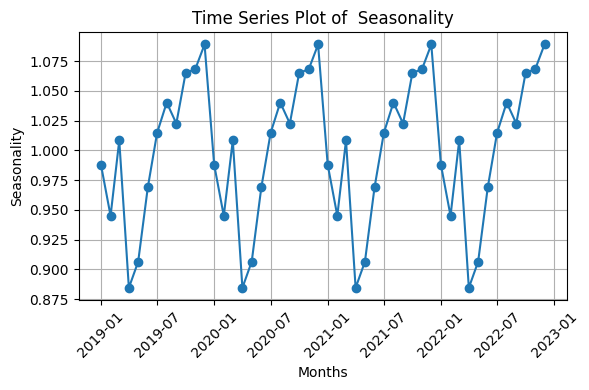

In [29]:
#seasonality calculation
df['month index']=df['date'].dt.month
df["Seasonality"] = df.groupby(['month index'])["kpi_val_sales_mn"].transform('mean')/df['kpi_val_sales_mn'].mean()

# Create time series plots for each variable
plt.figure(figsize=(6, 4))
plt.plot(df["date"], df["Seasonality"], marker='o')
plt.title(f'Time Series Plot of  Seasonality')
plt.xlabel('Months')
plt.ylabel('Seasonality')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
def apl_transformation(series, adstock_rate=0.5, power=0.5):
    result = []
    for i in range(len(series)):
        if i == 0:
            result.append(series[i] ** power)
        else:
            result.append((series[i] + adstock_rate * result[i - 1]) ** power)
    return result

# Define specific adstock_rate and power values for each tactic from domain knowledge
tactic_params = {
    'newspaper_impressions': {'adstock_rate': 0.8, 'power': 0.6},
    'tv_total_grp': {'adstock_rate': 0.8, 'power': 0.4},
    'google_display_impressions_mn': {'adstock_rate': 0.7, 'power': 0.8},
    'youtube_impressions_mn': {'adstock_rate': 0.7, 'power': 0.6},
    'fb_ig_impressions_mn': {'adstock_rate': 0.7, 'power': 0.6},
    'jio_impressions_mn': {'adstock_rate': 0.7, 'power': 0.8},
    'hotstar_impressions_mn': {'adstock_rate': 0.7, 'power': 0.6},
    'whatsapp_clicks': {'adstock_rate': 0.4, 'power': 0.8},
    'ventes_avenue_spends_mn': {'adstock_rate': 0.7, 'power': 0.6}
    }

# Apply APL transformation using the specific parameters
for column, params in tactic_params.items():
    df[column] = apl_transformation(df[column], adstock_rate=params['adstock_rate'], power=params['power'])

In [31]:
x = [col for col in df.columns if ('spots' in col.lower() or 'clicks' in col.lower() or col in {'vol_sales_mn','wtd_dist_max','kpi_val_sales_mn','month index','whatsapp_impressions_mn','competition1_newspaper_impressions','competition2_newspaper_impressions','competition1_tv_total_grp'})]
x.remove('whatsapp_clicks')
x

['kpi_val_sales_mn',
 'vol_sales_mn',
 'wtd_dist_max',
 'tv_spots',
 'competition1_newspaper_impressions',
 'competition1_tv_total_grp',
 'competition1_tv_spots',
 'competition2_newspaper_impressions',
 'competition2_tv_spots',
 'google_display_clicks',
 'youtube_clicks',
 'fb_ig_clicks',
 'whatsapp_impressions_mn',
 'jio_clicks',
 'hotstar_clicks',
 'month index']

In [32]:
# OLS-based MMM model
y = df['kpi_val_sales_mn']
X = df.drop(columns=['date']+ x)
X = sm.add_constant(X)


model = sm.OLS(y, X).fit()

# Model summary
model_summary = model.summary()
model_summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       kpi_val_sales_mn   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     70.06
Date:                Fri, 06 Jun 2025   Prob (F-statistic):           3.85e-20
Time:                        07:42:11   Log-Likelihood:                -178.99
No. Observations:                  48   AIC:                             390.0
Df Residuals:                      32   BIC:                             419.9
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                           114.5073    141.296      0.810      0.424    -173.303     402.317
num_dist_max                     10.2113      2.056      4.968      0.000       6.024      14.398
trade_promo_spends_mn             0.8653      0.722      1.198      0.240      -0.606       2.336
consumer_promo_spends_mn          0.3056      0.356      0.858      0.397      -0.420       1.031
newspaper_impressions            -1.8383      0.730     -2.518      0.017      -3.326      -0.351
tv_total_grp                     -0.5632      0.558     -1.009      0.321      -1.700       0.574
competition2_tv_total_grp        -0.0974      0.012     -7.927      0.000      -0.122      -0.072
google_display_impressions_mn    -4.7712      3.935     -1.212      0.234     -12.787       3.244
youtube_impressions_mn            0.1753      0.565      0.310      0.758      -0.975       1.326
fb_ig_impressions_mn              1.1513      0.699      1.647      0.109      -0.272       2.575
whatsapp_clicks                7.048e-05      0.001      0.136      0.893      -0.001       0.001
jio_impressions_mn                0.2243      0.292      0.768      0.448      -0.371       0.819
hotstar_impressions_mn            2.8471      2.290      1.243      0.223      -1.817       7.511
ventes_avenue_spends_mn           9.9453     11.293      0.881      0.385     -13.059      32.949
Price                          -248.5142    113.424     -2.191      0.036    -479.552     -17.477
Seasonality                      49.7696     37.868      1.314      0.198     -27.365     126.904
==============================================================================
Omnibus:                        0.871   Durbin-Watson:                   1.810
Prob(Omnibus):                  0.647   Jarque-Bera (JB):                0.760
Skew:                          -0.296   Prob(JB):                        0.684
Kurtosis:                       2.829   Cond. No.                     3.87e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.87e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [33]:
# Calculate R-squared and Adjusted R-squared
r_squared = model.rsquared
adj_r_squared = model.rsquared_adj
r_squared, adj_r_squared

(0.9704515858787247, 0.9566007667593769)

In [34]:
# Calculate MAPE
y_pred = model.predict(X)
mape = mean_absolute_percentage_error(y, y_pred)
mape

0.029999160807794762

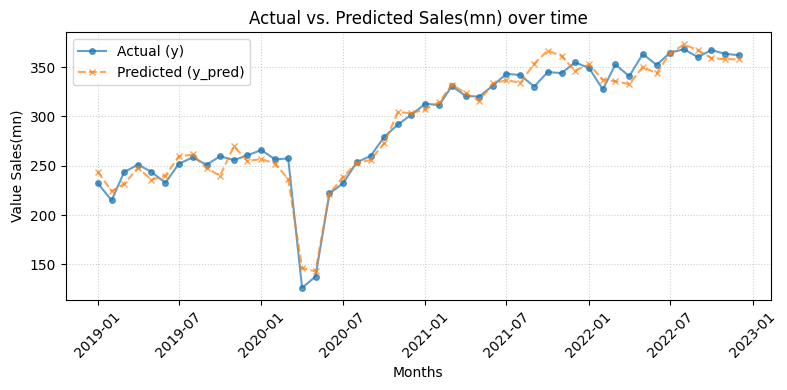

In [35]:
plt.figure(figsize=(8, 4))
# Plot actual values
plt.plot(df["date"], y, label='Actual (y)', marker='o', linestyle='-', markersize=4, alpha=0.7)
# Plot predicted values
plt.plot(df["date"], y_pred, label='Predicted (y_pred)', marker='x', linestyle='--', markersize=4, alpha=0.7)
plt.xlabel("Months")
plt.ylabel("Value Sales(mn)")
plt.title("Actual vs. Predicted Sales(mn) over time")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Improve x-axis date formatting
plt.xticks(rotation=45)
plt.tight_layout() # Adjusts plot to prevent labels from overlapping
plt.show()

In [36]:
with pd.ExcelWriter('Final_results.xlsx') as writer: model.params.to_frame().to_excel(writer, sheet_name='params'); X.to_excel(writer, sheet_name='Transformed_support')


In [37]:
model.params.to_frame()

,0
const,114.507297
num_dist_max,10.211272
trade_promo_spends_mn,0.865291
consumer_promo_spends_mn,0.305592
newspaper_impressions,-1.838268
tv_total_grp,-0.563169
competition2_tv_total_grp,-0.097375
google_display_impressions_mn,-4.771166
youtube_impressions_mn,0.175276
fb_ig_impressions_mn,1.151306


In [38]:
beta_df = model.params.to_frame()
beta_df.columns = ['Beta coefficient']
beta_df.set_index('Variable', inplace=True)

# Read the transformed support values from the 'Transformed_support' sheet
X_df =X.to_frame()
X_df.columns = X_df.iloc[0]
X_df = X_df[1:]
X_df.set_index(X_df.columns[0], inplace=True)

# Ensure all column names and index labels are strings and properly stripped
beta_df.index = beta_df.index.astype(str).str.strip()
X_df.columns = X_df.columns.astype(str).str.strip()

# Align the beta index and X columns by selecting only common labels
common_labels = beta_df.index.intersection(X_df.columns)
beta_series = beta_df.loc[common_labels, 'Beta coefficient']
X_df = X_df[common_labels]

# Compute the dot product (beta * X) for each row
result_df = X_df.dot(beta_series)

# Write the result to a new sheet named 'Beta_X_Product'
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a') as writer:
    result_df.to_excel(writer, sheet_name='Beta_X_Product')

print("Dot product (beta * X) has been computed and saved to 'Beta_X_Product' sheet.")


KeyError: "None of ['Variable'] are in the columns"